In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
df['sim'] = df['InternetService'].map({'Fiber optic':'Reliance Jio','DSL':'Airtel','phone':'Vodafone','No':'BSNL'}).astype(str)

In [ ]:
df.sample(100)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,sim
6017,4482-FTFFX,Male,0,No,No,5,Yes,No,DSL,No,...,Yes,No,No,Month-to-month,No,Electronic check,56.15,291.45,No,Airtel
1922,8201-AAXCB,Male,0,Yes,Yes,25,Yes,Yes,DSL,No,...,No,Yes,No,Month-to-month,No,Electronic check,60.35,1404.65,No,Airtel
3192,1231-YNDEK,Male,0,No,No,58,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),19.15,1035.5,No,BSNL
6851,8465-SBRXP,Male,0,Yes,Yes,38,Yes,Yes,Fiber optic,No,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),94.90,3616.25,No,Reliance Jio
6370,2869-ADAWR,Female,0,No,No,45,Yes,Yes,Fiber optic,No,...,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.30,4016.85,Yes,Reliance Jio
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3712,9209-NWPGU,Male,0,No,No,44,Yes,No,DSL,Yes,...,Yes,Yes,No,One year,No,Electronic check,65.40,2774.55,No,Airtel
2745,4826-XTSOH,Male,1,Yes,No,1,Yes,Yes,Fiber optic,No,...,No,Yes,No,Month-to-month,Yes,Electronic check,86.05,86.05,Yes,Reliance Jio
1738,8646-JCOMS,Female,0,Yes,No,66,Yes,Yes,Fiber optic,No,...,Yes,No,No,One year,Yes,Bank transfer (automatic),90.55,6130.95,No,Reliance Jio
50,8012-SOUDQ,Female,1,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,No,Month-to-month,Yes,Electronic check,90.25,3838.75,No,Reliance Jio


In [ ]:
df = df.drop(['sim'],axis=1)

In [ ]:
for i in df:
  print(i)

customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


In [ ]:
def add_sim(df):
  if df['PaymentMethod'] == 'Electronic check':
      return 'Reliance Jio'
  elif df['PaymentMethod'] == 'Mailed check':
      return 'Airtel'
  elif df['PaymentMethod'] == 'Bank transfer (automatic)':
      return 'Vi-idea'
  else:
      return 'BSNL'
df['Sim'] = df.apply(add_sim,axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
#handling missing values

df['TotalCharges'].isnull().sum()

np.int64(11)

In [ ]:
#mean

df['T_MEAN']= df['TotalCharges'].mean()

In [ ]:
t=pd.DataFrame()

t['Orignal_Std'] = df['TotalCharges'].std()
t['mean_std'] = df['T_MEAN'].std()
t

,Orignal_Std,mean_std


In [ ]:
df['T_MEAN']=df['TotalCharges'].fillna(df['TotalCharges'].mean())

print(f'the original standard dev {df['TotalCharges'].std()}')
print(f'the mean standard dev {df['T_MEAN'].std()}')

the original standard dev 2266.7713618831453
the mean standard dev 2265.0002578033277


In [ ]:
df['T_MEAN'].isnull().sum()

np.int64(0)

In [ ]:
df['TotalCharges'].median()

1397.475

In [ ]:
df['T_Median']=df['TotalCharges'].fillna(df['TotalCharges'].median())

print(f'the original standard dev {df['TotalCharges'].std()}')
print(f'the median standard dev {df['T_Median'].std()}')

the original standard dev 2266.7713618831453
the median standard dev 2265.2703984821865


In [ ]:
df['T_Median'].isnull().sum()

np.int64(0)

In [ ]:
df['T_MODE'] = df['TotalCharges'].fillna(df['TotalCharges'].mode()[0])
print(f'the original standard dev {df['TotalCharges'].std()}')
print(f'the median standard dev {df['T_MODE'].std()}')

the original standard dev 2266.7713618831453
the median standard dev 2266.7628761831656


In [ ]:
df['T_MODE'].isnull().sum()

np.int64(0)

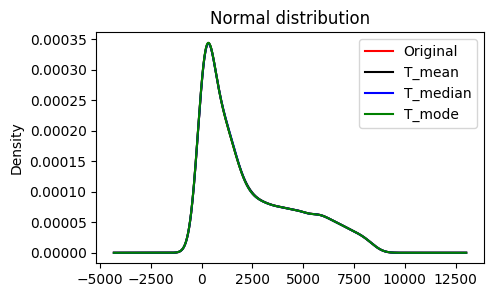

In [ ]:
plt.figure(figsize=(5,3))
plt.title('Normal distribution')
df['TotalCharges'].plot(kind='kde', color='r',label='Original')
df['T_MEAN'].plot(kind='kde',color='black',label='T_mean')
df['T_Median'].plot(kind='kde',color='blue',label='T_median')
df['T_MODE'].plot(kind='kde',color='green',label='T_mode')
plt.legend()
plt.show()

In [ ]:
value = df['TotalCharges'].mean()  + 3 * df['TotalCharges'].std()

In [ ]:
#END OF DISTRIBUTION

df['END_DISTR'] = df['TotalCharges'].fillna(value)

print(f'the original std {df['TotalCharges'].std()}')
print(f'the mean std {df['END_DISTR'].std()}')

the original std 2266.7713618831453
the mean std 2280.8659539256705


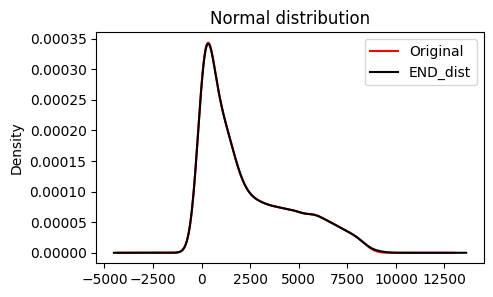

In [ ]:
plt.figure(figsize=(5,3))
plt.title('Normal distribution')
df['TotalCharges'].plot(kind='kde', color='r',label='Original')
df['END_DISTR'].plot(kind='kde',color='black',label='END_dist')

plt.legend()
plt.show()

In [ ]:
# 3. constant value technique

df['Cons_value'] = np.where(df['TotalCharges'].isnull(),1,0)
df

print(f'the original std {df['TotalCharges'].std()}')
print(f'the mean std {df['Cons_value'].std()}')

the original std 2266.7713618831453
the mean std 0.039491980968195006


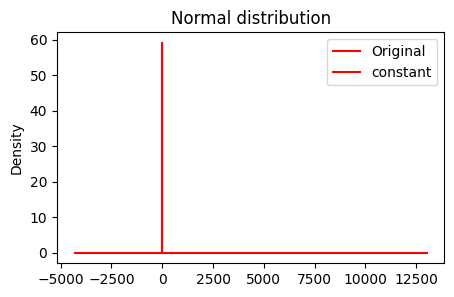

In [ ]:

plt.figure(figsize=(5,3))
plt.title('Normal distribution')
df['TotalCharges'].plot(kind='kde', color='r',label='Original')
df['Cons_value'].plot(kind='kde', color='r',label='constant')

plt.legend()
plt.show()

In [ ]:
# 4. arbitaray value technique

df['ARB_Value'] = df['TotalCharges'].fillna(999)
print(f'the original std {df['TotalCharges'].std()}')
print(f'the mean std {df['ARB_Value'].std()}')

the original std 2266.7713618831453
the mean std 2265.5680617639305


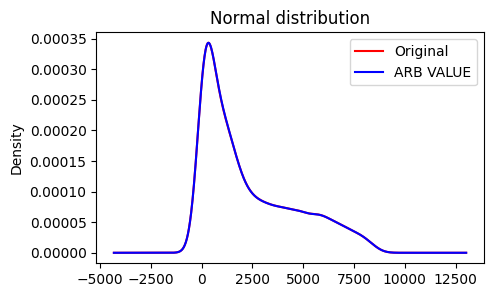

In [ ]:
plt.figure(figsize=(5,3))
plt.title('Normal distribution')
df['TotalCharges'].plot(kind='kde', color='r',label='Original')
df['ARB_Value'].plot(kind='kde',color='blue',label='ARB VALUE')
plt.legend()
plt.show()

In [ ]:
df['TotalCharges'].dropna().sample(df['TotalCharges'].isnull().sum())

,TotalCharges
4971,389.25
3652,25.25
1039,3013.05
2793,336.15
3464,2674.15
6539,1959.50
4189,4885.85
3680,328.95
5563,84.50
750,1652.95


In [ ]:
#5. random state
df['MI_SRT'] = df['TotalCharges'].copy()
s = df['TotalCharges'].dropna().sample(df['TotalCharges'].isnull().sum())
s.index =df[df['TotalCharges'].isnull()].index
df.loc[df['TotalCharges'].isnull() , 'MI_SRT'] = s

df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TotalCharges,Churn,Sim,T_MEAN,T_Median,T_MODE,END_DISTR,Cons_value,ARB_Value,MI_SRT
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,29.85,No,Reliance Jio,29.85,29.85,29.85,29.85,0,29.85,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,1889.50,No,Airtel,1889.50,1889.50,1889.50,1889.50,0,1889.50,1889.50
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,108.15,Yes,Airtel,108.15,108.15,108.15,108.15,0,108.15,108.15
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,1840.75,No,Vi-idea,1840.75,1840.75,1840.75,1840.75,0,1840.75,1840.75
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,151.65,Yes,Reliance Jio,151.65,151.65,151.65,151.65,0,151.65,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,1990.50,No,Airtel,1990.50,1990.50,1990.50,1990.50,0,1990.50,1990.50
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,7362.90,No,BSNL,7362.90,7362.90,7362.90,7362.90,0,7362.90,7362.90
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,346.45,No,Reliance Jio,346.45,346.45,346.45,346.45,0,346.45,346.45
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,306.60,Yes,Airtel,306.60,306.60,306.60,306.60,0,306.60,306.60


In [ ]:

print(f'the original std {df['TotalCharges'].std()}')
print(f'the standard {df['MI_SRT'].std()}')

the original std 2266.7713618831453
the standard 2266.4791759875066


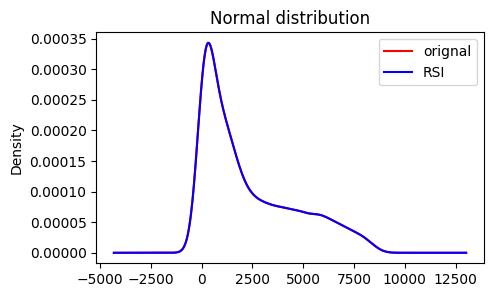

In [ ]:
plt.figure(figsize=(5,3))
plt.title('Normal distribution')
df['TotalCharges'].plot(kind='kde', color='r',label='orignal')
df['MI_SRT'].plot(kind='kde',color='b',label='RSI')
plt.legend()
plt.show()

In [ ]:
#6. forwardfill

df['T_For'] = df['TotalCharges'].fillna(method='ffill')


/tmp/ipykernel_3619/1357774505.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['T_For'] = df['TotalCharges'].fillna(method='ffill')


In [ ]:
df['T_For'].isnull().sum()

np.int64(0)

In [ ]:

print(f'the original std {df['TotalCharges'].std()}')
print(f'the standard {df['T_For'].std()}')

the original std 2266.7713618831453
the standard 2267.54451124036


In [ ]:
#backward fill

df['T_Bac'] = df['TotalCharges'].fillna(method='bfill')

/tmp/ipykernel_3619/983165821.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['T_Bac'] = df['TotalCharges'].fillna(method='bfill')


In [ ]:
df['T_Bac'].isnull().sum()

np.int64(0)

In [ ]:

print(f'the original std {df['TotalCharges'].std()}')
print(f'the standard {df['T_Bac'].std()}')

the original std 2266.7713618831453
the standard 2266.7829776445146


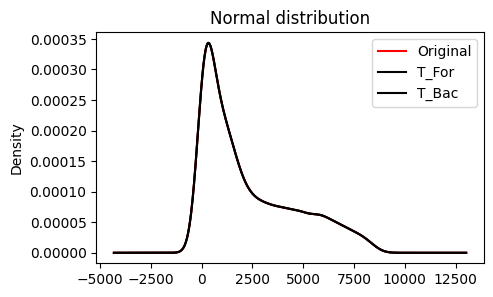

In [ ]:
plt.figure(figsize=(5,3))
plt.title('Normal distribution')
df['TotalCharges'].plot(kind='kde', color='r',label='Original')
df['T_For'].plot(kind='kde',color='black',label='T_For')
df['T_Bac'].plot(kind='kde',color='black',label='T_Bac')

plt.legend()
plt.show()

In [ ]:
#interpolation

df['T_Linear_Polation'] = df['TotalCharges'].interpolate(method='linear')

df['T_Linear_Polation'].isnull().sum()

np.int64(0)

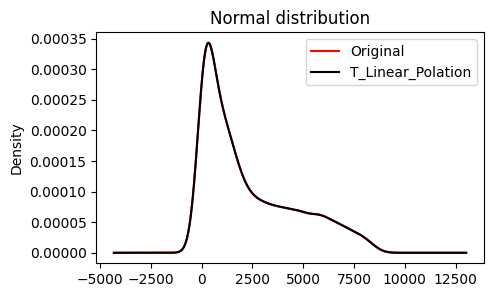

In [ ]:
plt.figure(figsize=(5,3))
plt.title('Normal distribution')
df['TotalCharges'].plot(kind='kde', color='r',label='Original')
df['T_Linear_Polation'].plot(kind='kde',color='black',label='T_Linear_Polation')
plt.legend()
plt.show()

In [ ]:
df.loc[df['TotalCharges'].isnull(), ['TotalCharges', 'T_Linear_Polation']]

,TotalCharges,T_Linear_Polation
488,NaN,3138.150
753,NaN,353.125
936,NaN,371.275
1082,NaN,2368.025
1340,NaN,3651.350
3331,NaN,2479.800
3826,NaN,533.250
4380,NaN,5245.075
5218,NaN,145.375
6670,NaN,4794.725


In [ ]:
#KNN imputer



from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import KNNImputer


reg = KNNImputer(n_neighbors=5)
reg.fit(df[['TotalCharges']])
df[['KNNIMPUTER_TotalCharges']] = reg.transform(df[['TotalCharges']])



In [ ]:
df['KNNIMPUTER_TotalCharges'].isnull().sum()

np.int64(0)

In [ ]:
df[df['TotalCharges'].isnull() == True][['KNNIMPUTER_TotalCharges']]

,KNNIMPUTER_TotalCharges
488,2283.300441
753,2283.300441
936,2283.300441
1082,2283.300441
1340,2283.300441
3331,2283.300441
3826,2283.300441
4380,2283.300441
5218,2283.300441
6670,2283.300441


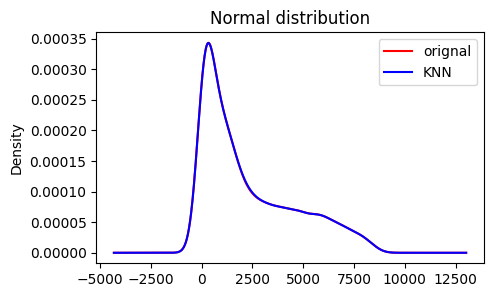

In [ ]:
plt.figure(figsize=(5,3))
plt.title('Normal distribution')
df['TotalCharges'].plot(kind='kde', color='r',label='orignal')
df['KNNIMPUTER_TotalCharges'].plot(kind='kde',color='b',label='KNN')
plt.legend()
plt.show()

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Sim',
       'T_MEAN', 'T_Median', 'T_MODE', 'END_DISTR', 'Cons_value', 'ARB_Value',
       'MI_SRT', 'T_For', 'T_Bac', 'T_Linear_Polation',
       'KNNIMPUTER_TotalCharges'],
      dtype='object')

In [ ]:
t = pd.DataFrame({
    'Original_Std'          : [df['TotalCharges'].std()],
    'Mean_Std'              : [df['T_MEAN'].std()],
    'Median_Std'            : [df['T_Median'].std()],
    'Mode_Std'              : [df['T_MODE'].std()],
    'End_Distribution_Std'  : [df['END_DISTR'].std()],
    'Constant_Std'          : [df['Cons_value'].std()],
    'Arbitrary_Std'         : [df['ARB_Value'].std()],
    'RandomSample_Std'      : [df['MI_SRT'].std()],
    'ForwardFill_Std'       : [df['T_For'].std()],
    'BackwardFill_Std'      : [df['T_Bac'].std()],
    'LinearInterp_Std'      : [df['T_Linear_Polation'].std()],
    'KNN_Std'               : [df['KNNIMPUTER_TotalCharges'].std()]
})

t

,Original_Std,Mean_Std,Median_Std,Mode_Std,End_Distribution_Std,Constant_Std,Arbitrary_Std,RandomSample_Std,ForwardFill_Std,BackwardFill_Std,LinearInterp_Std,KNN_Std
0,2266.771362,2265.000258,2265.270398,2266.762876,2280.865954,0.039492,2265.568062,2266.479176,2267.544511,2266.782978,2266.077835,2265.000258


In [ ]:
# we are going to use the mode